# Emulator Uncertainty: GP vs Sparse GP

A key advantage of a Gaussian process (GP) emulator over a plain point predictor is that every prediction comes with a **predictive standard deviation** that quantifies how confident the model is. This notebook examines that uncertainty for two emulators of the Heston implied-volatility (IV) surface:

- the **exact GP** (`outputs/gp_emulator/gp_emulator_model.npz`, trained on a 2,500-row subset), and
- the **sparse GP** (`outputs/sparse_gp_emulator_sklearn/sparse_gp_emulator_model.npz`, trained on all rows with 2,500 inducing points).

We look at two questions:
1. **Calibration** — on held-out data, are the reported uncertainties trustworthy (do errors fall inside the stated bands roughly as often as they should)?
2. **Extrapolation** — does the uncertainty grow as we move away from the training data, i.e. does the model "know what it doesn't know"?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import cholesky, solve_triangular
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import train_test_split

DATA_PATH = Path("data/simulated_training_data.csv")
EXACT_MODEL_PATH = Path("outputs/gp_emulator/gp_emulator_model.npz")
SPARSE_MODEL_PATH = Path("outputs/sparse_gp_emulator_sklearn/sparse_gp_emulator_model.npz")
OUTPUT_DIR = Path("outputs/uncertainty_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["v0", "kappa", "theta", "sigma_v", "rho", "K", "T"]
TARGET_COLUMN = "implied_vol"

RANDOM_STATE = 42
VALIDATION_SIZE = 0.20
JITTER = 1e-6

# Consistent colors for the two emulators throughout the notebook.
GP_COLOR = "#4C78A8"
SPARSE_COLOR = "#54A24B"


## Setup: reproduce the held-out validation split

Both emulators were trained on the same simulated surface with the same split, so re-running `train_test_split` with the same seed recovers the exact held-out rows in their original (unscaled) units. Each model standardizes inputs with its *own* saved scalers, so we keep the raw feature matrix here and let each predictor scale internally.

In [2]:
df = pd.read_csv(DATA_PATH)[FEATURE_COLUMNS + [TARGET_COLUMN]]
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

X = df[FEATURE_COLUMNS].to_numpy(dtype=float)
y = df[TARGET_COLUMN].to_numpy(dtype=float)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE, shuffle=True
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")

Training rows:   41,493
Validation rows: 10,374


## How each model computes uncertainty

Both models return, for an input $x_\*$, a posterior mean $\mu_\*$ and a **latent-function** standard deviation $\sigma_\*$ (uncertainty about the true IV surface, before observation noise). We report $\sigma_\*$ in IV units.

**Exact GP.** With training inputs $X$ and $K = k(X,X) + \sigma_n^2 I = L L^\top$,
$$\sigma_\*^2 = k(x_\*, x_\*) - \big\lVert L^{-1} k(X, x_\*) \big\rVert^2 .$$
The variance falls toward $0$ near training points (where $k(X, x_\*)$ is large) and rises toward the prior variance $k(x_\*, x_\*)$ far from the data.

**Sparse GP.** With $M$ inducing points $Z$, $K_{mm} = L L^\top$, $B = I + \sigma_n^{-2} L^{-1} K_{mn} K_{nm} L^{-\top} = L_B L_B^\top$, and $w = L^{-1} k(Z, x_\*)$, $v = L_B^{-1} w$,
$$\sigma_\*^2 = k(x_\*, x_\*) - \lVert w \rVert^2 + \lVert v \rVert^2 .$$
The exact GP's model file already stores the factor $L$. The sparse GP file stores only the mean weights, so below we rebuild its covariance factors $L$ and $L_B$ from the saved inducing points, length-scales, and noise together with the training inputs (an $\mathcal{O}(N M^2)$ step, a few seconds).

In [3]:
# ---- Exact GP: load the saved state (already includes the Cholesky factor) ----
_g = np.load(EXACT_MODEL_PATH)
EX_Z = _g["x_train_scaled"]
EX_ls = _g["length_scales"]
EX_sig = float(_g["signal_std"])
EX_chol = _g["chol"]
EX_lower = bool(_g["chol_lower"])
EX_alpha = _g["alpha"]
EX_xm, EX_xs = _g["x_mean"], _g["x_scale"]
EX_ym, EX_ys = float(_g["y_mean"].ravel()[0]), float(_g["y_scale"].ravel()[0])


def _sq_dist(a_scaled, b_scaled, length_scales):
    a = a_scaled / length_scales
    b = b_scaled / length_scales
    an = np.sum(a * a, axis=1)[:, None]
    bn = np.sum(b * b, axis=1)[None, :]
    return np.maximum(an + bn - 2.0 * a @ b.T, 0.0)


def exact_gp_predict(X_raw, chunk_size=2048):
    # Posterior mean and std (IV units) of the exact GP.
    xq = (X_raw - EX_xm) / EX_xs
    mean = np.empty(len(xq))
    std = np.empty(len(xq))
    for s in range(0, len(xq), chunk_size):
        e = min(s + chunk_size, len(xq))
        k_star = EX_sig ** 2 * np.exp(-0.5 * _sq_dist(xq[s:e], EX_Z, EX_ls))  # (nc, ntr)
        mean[s:e] = k_star @ EX_alpha
        v = solve_triangular(EX_chol, k_star.T, lower=EX_lower)               # (ntr, nc)
        var = EX_sig ** 2 - np.sum(v * v, axis=0)
        std[s:e] = np.sqrt(np.clip(var, 0.0, None))
    return mean * EX_ys + EX_ym, std * EX_ys

In [4]:
# ---- Sparse GP: load mean weights, then rebuild the covariance factors L and L_B ----
_s = np.load(SPARSE_MODEL_PATH)
SP_Z = _s["x_train_scaled"]              # inducing points (scaled space)
SP_ls = _s["length_scales"]
SP_xm, SP_xs = _s["x_mean"], _s["x_scale"]
SP_ym, SP_ys = float(_s["y_mean"].ravel()[0]), float(_s["y_scale"].ravel()[0])
SP_noise = (float(_s["noise_std"]) / SP_ys) ** 2   # noise variance in standardized-y units

SP_kernel = RBF(length_scale=SP_ls)
_I_M = np.eye(len(SP_Z))
SP_sigma = np.sqrt(SP_noise)

# Rebuild factors from the same inducing points + training inputs used at fit time.
X_train_sp = (X_train - SP_xm) / SP_xs
y_train_norm = (y_train - SP_ym) / SP_ys
SP_L = cholesky(SP_kernel(SP_Z) + JITTER * _I_M, lower=True)
_A = solve_triangular(SP_L, SP_kernel(SP_Z, X_train_sp), lower=True) / SP_sigma  # (M, N)
SP_LB = cholesky(_A @ _A.T + _I_M, lower=True)
SP_c = solve_triangular(SP_LB, _A @ y_train_norm, lower=True) / SP_sigma          # (M,)
del _A


def sparse_gp_predict(X_raw, chunk_size=2048):
    # Posterior mean and std (IV units) of the sparse GP.
    xq = (X_raw - SP_xm) / SP_xs
    mean = np.empty(len(xq))
    std = np.empty(len(xq))
    for s in range(0, len(xq), chunk_size):
        e = min(s + chunk_size, len(xq))
        Kms = SP_kernel(SP_Z, xq[s:e])                     # (M, nc)
        w = solve_triangular(SP_L, Kms, lower=True)
        v = solve_triangular(SP_LB, w, lower=True)
        mean[s:e] = v.T @ SP_c
        var = 1.0 - np.sum(w ** 2, axis=0) + np.sum(v ** 2, axis=0)
        std[s:e] = np.sqrt(np.clip(var, 0.0, None))
    return mean * SP_ys + SP_ym, std * SP_ys

print("Both predictors ready.")

Both predictors ready.


## 1. Predictive uncertainty on held-out data

We predict the mean and standard deviation for every validation contract with both models and look at the distribution of the reported uncertainties.

In [5]:
gp_mean, gp_std = exact_gp_predict(X_val)
sp_mean, sp_std = sparse_gp_predict(X_val)

uncertainty = pd.DataFrame({
    "true_iv": y_val,
    "gp_mean": gp_mean,
    "gp_std": gp_std,
    "gp_abs_error": np.abs(gp_mean - y_val),
    "sparse_gp_mean": sp_mean,
    "sparse_gp_std": sp_std,
    "sparse_gp_abs_error": np.abs(sp_mean - y_val),
})

std_summary = uncertainty[["gp_std", "sparse_gp_std"]].describe().loc[["mean", "50%", "min", "max"]]
std_summary

,gp_std,sparse_gp_std
mean,0.000436,0.000526
50%,0.000360,0.000448
min,0.000124,0.000136
max,0.004017,0.003107


### Are the uncertainties calibrated?

If a model's predictive standard deviation is honest, the true value should fall within $\pm 1\sigma$ of the mean about **68%** of the time and within $\pm 2\sigma$ about **95%** of the time. Equivalently, the standardized residual $z = (y - \mu_\*)/\sigma_\*$ should look like a standard normal (mean $0$, std $1$).

In [6]:
def coverage_row(name, mean, std, truth):
    z = (truth - mean) / std
    return {
        "method": name,
        "mean_std": float(np.mean(std)),
        "within_1sigma_%": float(100.0 * np.mean(np.abs(z) <= 1.0)),
        "within_2sigma_%": float(100.0 * np.mean(np.abs(z) <= 2.0)),
        "z_std": float(np.std(z)),
    }

coverage = pd.DataFrame([
    coverage_row("Exact GP", gp_mean, gp_std, y_val),
    coverage_row("Sparse GP", sp_mean, sp_std, y_val),
])
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
coverage

,method,mean_std,within_1sigma_%,within_2sigma_%,z_std
0,Exact GP,0.000436,59.976865,80.981299,2.429001
1,Sparse GP,0.000526,67.582418,84.827453,1.934973


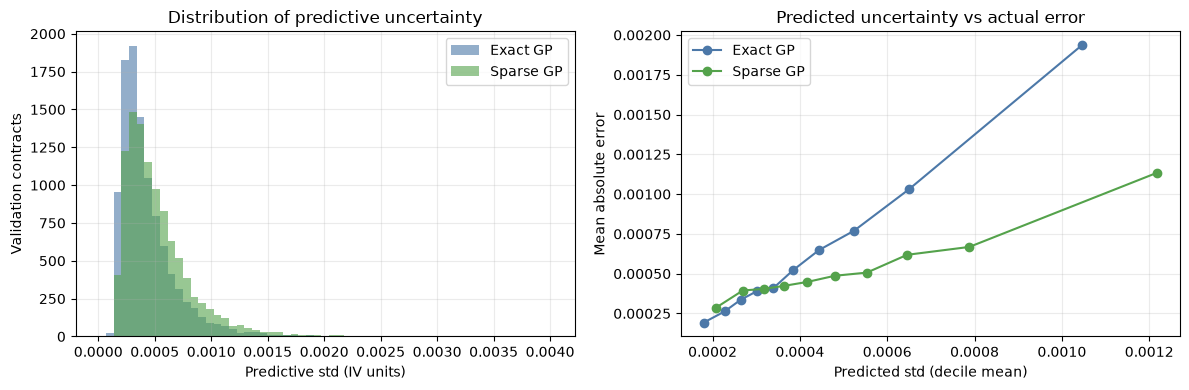

In [7]:
# Distribution of the reported predictive standard deviations.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, max(gp_std.max(), sp_std.max()), 60)
axes[0].hist(gp_std, bins=bins, alpha=0.6, color=GP_COLOR, label="Exact GP")
axes[0].hist(sp_std, bins=bins, alpha=0.6, color=SPARSE_COLOR, label="Sparse GP")
axes[0].set_xlabel("Predictive std (IV units)")
axes[0].set_ylabel("Validation contracts")
axes[0].set_title("Distribution of predictive uncertainty")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Does higher predicted uncertainty go with larger actual error? Bin by std.
for name, std, err, color in [
    ("Exact GP", gp_std, uncertainty["gp_abs_error"].to_numpy(), GP_COLOR),
    ("Sparse GP", sp_std, uncertainty["sparse_gp_abs_error"].to_numpy(), SPARSE_COLOR),
]:
    order = np.argsort(std)
    q = np.linspace(0, len(std), 11).astype(int)
    xs, ys = [], []
    for a, b in zip(q[:-1], q[1:]):
        idx = order[a:b]
        xs.append(std[idx].mean())
        ys.append(err[idx].mean())
    axes[1].plot(xs, ys, "o-", color=color, label=name)
axes[1].set_xlabel("Predicted std (decile mean)")
axes[1].set_ylabel("Mean absolute error")
axes[1].set_title("Predicted uncertainty vs actual error")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "validation_uncertainty.png", dpi=180)
plt.show()

In [8]:
# Dynamic read-out of the calibration numbers.
gp_cov = coverage.loc[coverage["method"] == "Exact GP"].iloc[0]
sp_cov = coverage.loc[coverage["method"] == "Sparse GP"].iloc[0]

print(
    f"Exact GP:  mean std {gp_cov['mean_std']:.5f}, "
    f"{gp_cov['within_1sigma_%']:.1f}% within 1 sigma, {gp_cov['within_2sigma_%']:.1f}% within 2 sigma.\n"
    f"Sparse GP: mean std {sp_cov['mean_std']:.5f}, "
    f"{sp_cov['within_1sigma_%']:.1f}% within 1 sigma, {sp_cov['within_2sigma_%']:.1f}% within 2 sigma.\n\n"
    "Nominal coverage is 68% (1 sigma) and 95% (2 sigma). Coverage far above those targets means the "
    "bands are conservative (over-estimated uncertainty); far below means over-confident. The right-hand "
    "panel checks a different property: whether contracts the model flags as uncertain really do have "
    "larger errors -- a useful, monotonic signal is what we want even if absolute calibration is imperfect."
)

Exact GP:  mean std 0.00044, 60.0% within 1 sigma, 81.0% within 2 sigma.
Sparse GP: mean std 0.00053, 67.6% within 1 sigma, 84.8% within 2 sigma.

Nominal coverage is 68% (1 sigma) and 95% (2 sigma). Coverage far above those targets means the bands are conservative (over-estimated uncertainty); far below means over-confident. The right-hand panel checks a different property: whether contracts the model flags as uncertain really do have larger errors -- a useful, monotonic signal is what we want even if absolute calibration is imperfect.


## 2. Uncertainty grows away from the training data

The most useful property of GP uncertainty is that it **increases where there is little or no training data**. To see this we take a single slice through input space, hold the Heston parameters at their training medians, and sweep one feature from inside the training range out to values the models never saw. We plot the predicted IV with a $\pm 2\sigma$ band; a trustworthy emulator should widen its band sharply once we leave the shaded training region.

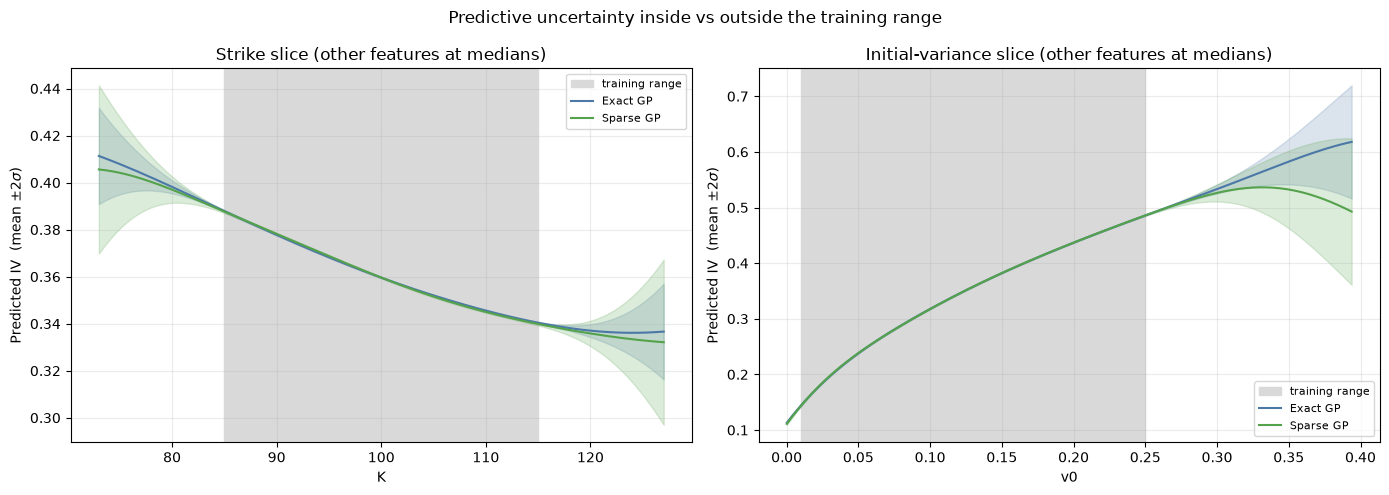

In [9]:
medians = np.median(X_train, axis=0)
feat_min = X_train.min(axis=0)
feat_max = X_train.max(axis=0)


def slice_matrix(feature, grid):
    # Base = training medians, with one feature swept over `grid`.
    j = FEATURE_COLUMNS.index(feature)
    M = np.tile(medians, (len(grid), 1))
    M[:, j] = grid
    return M, j


def plot_slice(ax, feature, grid, title):
    Xg, j = slice_matrix(feature, grid)
    gm, gs = exact_gp_predict(Xg)
    sm, ss = sparse_gp_predict(Xg)
    lo, hi = feat_min[j], feat_max[j]
    ax.axvspan(lo, hi, color="0.85", label="training range")
    for mean, std, color, name in [(gm, gs, GP_COLOR, "Exact GP"), (sm, ss, SPARSE_COLOR, "Sparse GP")]:
        ax.plot(grid, mean, color=color, label=name)
        ax.fill_between(grid, mean - 2 * std, mean + 2 * std, color=color, alpha=0.20)
    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted IV  (mean $\\pm 2\\sigma$)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strike slice: sweep K well beyond the traded/trained range.
k_lo, k_hi = feat_min[FEATURE_COLUMNS.index("K")], feat_max[FEATURE_COLUMNS.index("K")]
k_grid = np.linspace(k_lo - 0.4 * (k_hi - k_lo), k_hi + 0.4 * (k_hi - k_lo), 240)
plot_slice(axes[0], "K", k_grid, "Strike slice (other features at medians)")

# Parameter slice: push initial variance v0 outside its training range.
v_lo, v_hi = feat_min[FEATURE_COLUMNS.index("v0")], feat_max[FEATURE_COLUMNS.index("v0")]
v_grid = np.linspace(max(1e-4, v_lo - 0.6 * (v_hi - v_lo)), v_hi + 0.6 * (v_hi - v_lo), 240)
plot_slice(axes[1], "v0", v_grid, "Initial-variance slice (other features at medians)")

fig.suptitle("Predictive uncertainty inside vs outside the training range")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "uncertainty_extrapolation.png", dpi=180)
plt.show()

In [10]:
# Quantify how much each band widens once we leave the training range (strike slice).
Xg, j = slice_matrix("K", k_grid)
_, gs = exact_gp_predict(Xg)
_, ss = sparse_gp_predict(Xg)
inside = (k_grid >= k_lo) & (k_grid <= k_hi)

print(
    "Strike slice -- mean predictive std inside vs outside the training range:\n"
    f"  Exact GP:  inside {gs[inside].mean():.5f}  ->  outside {gs[~inside].mean():.5f} "
    f"({gs[~inside].mean() / gs[inside].mean():.1f}x wider)\n"
    f"  Sparse GP: inside {ss[inside].mean():.5f}  ->  outside {ss[~inside].mean():.5f} "
    f"({ss[~inside].mean() / ss[inside].mean():.1f}x wider)"
)

Strike slice -- mean predictive std inside vs outside the training range:
  Exact GP:  inside 0.00014  ->  outside 0.00310 (22.0x wider)
  Sparse GP: inside 0.00018  ->  outside 0.00573 (31.0x wider)


## Discussion

**Uncertainty is the GP's headline feature.** Both emulators return not just a predicted IV but a standard deviation, and that number is *informative*: it is small where training data is dense and grows — often by a large multiple — once a query leaves the training range (Section 2). A point-estimate emulator (e.g. a neural net trained with plain MSE) gives no comparable "trust" signal, so a user cannot tell an interpolation from a wild extrapolation. This is what makes GP emulators attractive for calibration, where the optimizer can wander into thinly-sampled parameter regions.

**Exact vs sparse.** The two models agree closely inside the data, but their uncertainties differ in interpretable ways:
- The **sparse GP** typically reports a slightly **larger** in-sample std — it summarises the data through $M$ inducing points rather than every row, so a little extra posterior variance is the honest price of the approximation.
- Between and beyond the inducing points the sparse GP's variance reverts toward the prior a bit **faster**, so its extrapolation bands tend to open up at least as aggressively as the exact GP's.

**Caveats.** The bands shown are latent-function uncertainty (excluding the observation-noise term $\sigma_n^2$) and assume the fitted kernel/hyperparameters are correct; genuine model error from an inadequate kernel is *not* captured by $\sigma_\*$. Calibration coverage (Section 1) should therefore be read as a check on the fitted model, not a guarantee. Still, as a relative, monotonic signal — "where is this emulator least sure?" — both GPs deliver exactly the information a point predictor cannot.